## FORECAST

### 1. Problematica

Los pronósticos comerciales consisten en herramientas y técnicas utilizadas para predecir cambios en los negocios, como ventas, gastos, ganancias y pérdidas. El objetivo de la previsión empresarial es desarrollar mejores estrategias basadas en estas predicciones informadas; ayudando a eliminar fallas o pérdidas potenciales antes de que sucedan. 

### 2. Obtener la data

In [40]:
## Cargar la data del CSV

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(r'C:\Users\victo\OneDrive\Documentos\python\practica_ciencia de datos\Cencosud\Data\Sales_data.csv')
df = df.dropna()

### 3. Analizar la data

Para convertir la variable de tipo object a tipo datetime puede usar el código de abajo. 

df['Date'] = pd.to_datetime(df['Date'])


In [41]:
# Analizar la data y dar una breve descripción de lo que se observa
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [42]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1615 non-null   datetime64[ns]
 1   Sales   1615 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 25.4 KB


,Date,Sales
0,2013-01-01,770
1,2013-01-02,1038
2,2013-01-03,887
3,2013-01-04,1054
4,2013-01-05,1355


### 4. Prepara la data



In [ ]:
# Preparar la data si lo consideran necesario.

df[year] = df['Date'].dt.year
df[month] = df['Date'].dt.month
df[day] = df['Date'].dt.day



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1615 non-null   datetime64[ns]
 1   Sales   1615 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 25.4 KB


<Axes: xlabel='Date'>

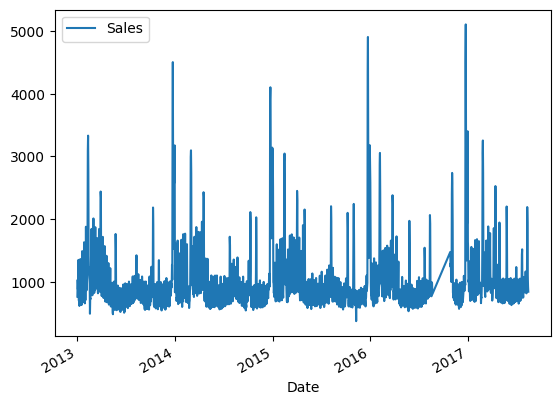

In [43]:
df.info()

df.plot(x='Date', y='Sales', kind='line')

In [31]:
# Particionar la data en train y test, 
# Para este ejercicio las ventas menores a la fecha 2017-08-01 se usará para data de entrenamiento y 
# las ventas mayores iguales a la fecha 2017-08-01 se usará para la data de prueba

train = df[df['Date'] < '2017-08-01']
test = df[df['Date'] >= '2017-08-01']

### 5 Entrenar el modelo

Mean Squared Error: 194022.7623016753
R^2 Score: -0.2663045949042382


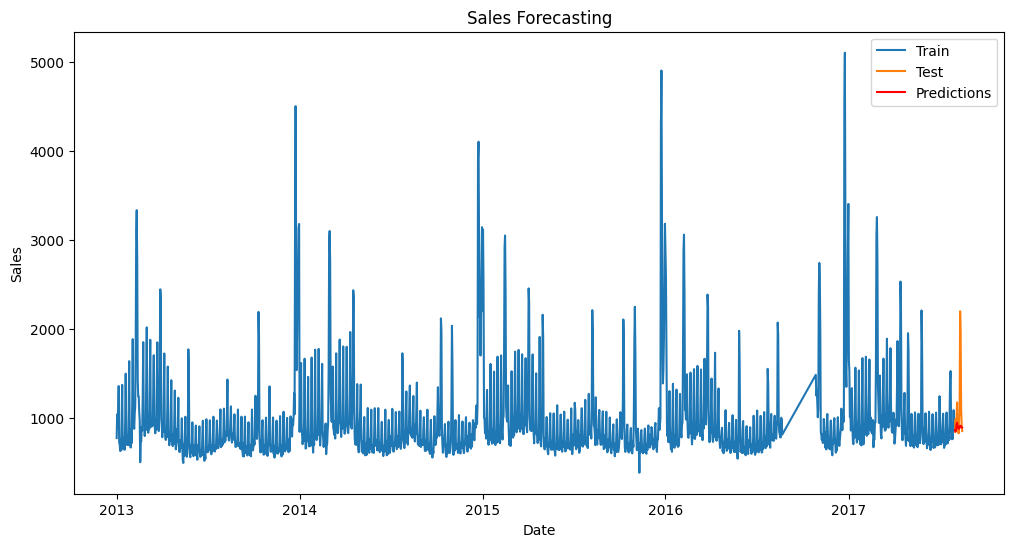

In [45]:
# Seleccionar un modelo de forecasting de varios que existen para predecir las ventas
# puede usar ARIMA, SARIMA, SARIMAX u otros modelos que conozca

# Definir el modelo ARIMA
model = ARIMA(train['Sales'], order=(5, 1, 0)) # p=5, d=1, q=0
# Ajustar el modelo
model_fit = model.fit()
# Hacer predicciones
predictions = model_fit.forecast(steps=len(test))
# Calcular el error cuadrático medio (MSE) y el coeficiente de determinación (R^2)
mse = mean_squared_error(test['Sales'], predictions)
r2 = r2_score(test['Sales'], predictions)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
# Graficar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(train['Date'], train['Sales'], label='Train')
plt.plot(test['Date'], test['Sales'], label='Test')
plt.plot(test['Date'], predictions, label='Predictions', color='red')
plt.title('Sales Forecasting')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()





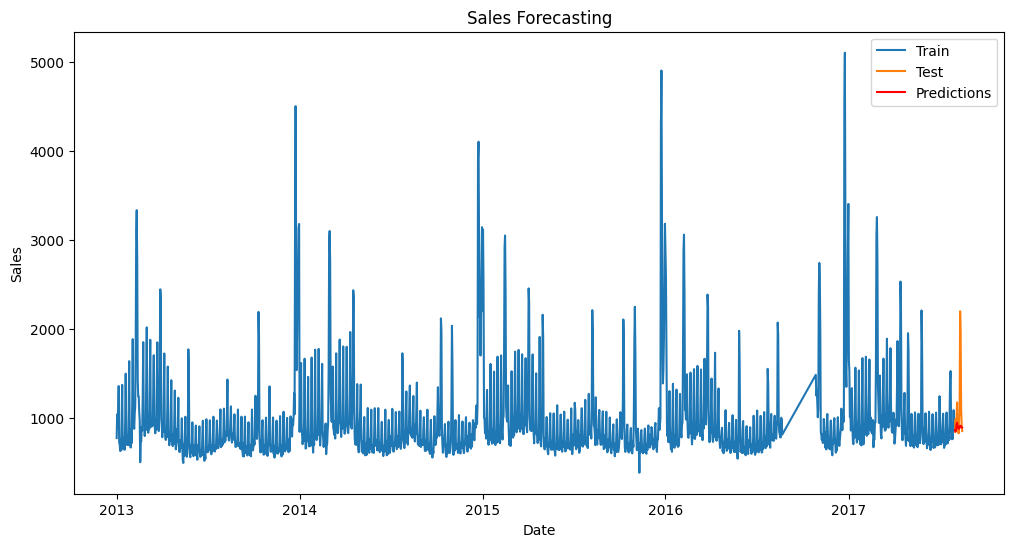

In [46]:
## Gráficar los resultados pronosticados y la data real
plt.figure(figsize=(12, 6))
plt.plot(train['Date'], train['Sales'], label='Train')
plt.plot(test['Date'], test['Sales'], label='Test')
plt.plot(test['Date'], predictions, label='Predictions', color='red')
plt.title('Sales Forecasting')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()



### 6 Métricas

In [47]:
# metricas de la data pronosticada y la data de prueba
# puede usar metricas como MAPE, RMSE, RSM

mse = mean_squared_error(test['Sales'], predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test['Sales'] - predictions) / test['Sales'])) * 100
r2 = r2_score(test['Sales'], predictions)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')
print(f'R^2 Score: {r2}')



Mean Squared Error: 194022.7623016753
Root Mean Squared Error: 440.48014972490563
Mean Absolute Percentage Error: 15.16291120676736
R^2 Score: -0.2663045949042382
